# M8.3B — Receptive field / spatial resolution

Plan: [`plans/milestone_08/08_single_view_localization_plan.md`](../../plans/milestone_08/08_single_view_localization_plan.md).  
**Not in Final Report.**

**Hypothesis:** Is the receptive field too small, or downsampling too aggressive, to integrate the anomaly pattern?

**Conclusion (Milestone 8 Step 3B):** Secondary check after Milestone 8 Step 3A spatial readout. Compare Fourier depth and downsampling against a **Flatten** absolute reference on validation RMSE. Do **not** freeze architecture here (Milestone 8 Step 3E).

Each variant is trained **`N_REPEAT=5`** times with distinct seeds; bars show **mean ± std**. Smoke defaults (`SMOKE=True`) keep wall time low; set `SMOKE=False` for the full 200-epoch study. If `win3b_receptive_field_runs.csv` exists, plots load it without retraining.


In [1]:
from pathlib import Path
import shutil
import sys
import subprocess

ROOT = Path.cwd()
while not (ROOT / "pyproject.toml").exists():
    if ROOT == ROOT.parent:
        raise RuntimeError("Could not locate repository root containing pyproject.toml")
    ROOT = ROOT.parent

# Concurrent notebook installs race on ./build (Errno 17 File exists).
for name in ("build", "dist"):
    shutil.rmtree(ROOT / name, ignore_errors=True)
for egg in (ROOT / "src").glob("*.egg-info"):
    shutil.rmtree(egg, ignore_errors=True)

subprocess.check_call(
    [
        sys.executable,
        "-m",
        "pip",
        "install",
        "--quiet",
        "--no-cache-dir",
        f"{ROOT}[dl,dev]",
        "-c",
        str(ROOT / "requirements.txt"),
    ]
)

from gummybear.paths import display_path

print(f"ROOT={display_path(ROOT)}")



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
ROOT=.


In [2]:
from tomography_ml_validation.milestone_08 import m8_corpus_paths, describe_paths

DATA_MODE = "full" if (ROOT / "data/generated/m8_1/single_particle").is_dir() else "demo"
paths = m8_corpus_paths(ROOT, data_mode=DATA_MODE)
print(f"DATA_MODE={DATA_MODE}")
print(describe_paths(paths))


DATA_MODE=full
workbook_path=configs/m8/localization_single_particle.xlsx  output_root=data/generated/m8_1/single_particle  cache_root=data/generated/m8_1/single_particle/_cache


In [3]:
from IPython.display import Markdown, display
import matplotlib.pyplot as plt
import torch

from tomography_ml import get_device
from tomography_ml.gummybear_data_catalog.task_dataset import build_task_dataset
from tomography_ml.localization import win3b_receptive_field_grid
from tomography_ml.studies import M8_CANONICAL_LR_BY_ARCH
from tomography_ml_validation.milestone_08 import (
    DEFAULT_N_REPEAT,
    architecture_grid_dataframe,
    load_m8_catalog_rows,
    load_win3b_results,
    plot_win3b_receptive_field_results,
    run_win3b_receptive_field_study,
    summarize_win3b_receptive_field,
    win3_grids_summary,
    win3b_results_dir,
    win3b_task_specs,
)
import tomography_ml_validation.milestone_08.validation as m8_validation
from gummybear_validation.notebook_tools import run_installed_pytest_test

from tomography_ml_validation.milestone_08 import DEFAULT_N_REPEAT

SMOKE = False
RUN_STUDY = None  # None = auto (run when runs CSV missing)
N_REPEAT = DEFAULT_N_REPEAT  # distinct training seeds per variant
BASE_SEED = 0
NUM_EPOCHS = 40 if SMOKE else 200
EARLY_STOP = 25 if SMOKE else 40

device = get_device()
results_dir = win3b_results_dir(ROOT)
print(f"device={device}")
print("canonical LRs", M8_CANONICAL_LR_BY_ARCH)
print(f"results_dir={display_path(results_dir)}")


device=mps
canonical LRs {'pooled': 0.001, 'fourier': 0.03, 'flatten': 0.0003}
results_dir=checkpoints/m8/m08_3b_receptive_field


## Milestone 8 Step 3B predefined grid

**Depth / RF axis** — more conv blocks (`shallow` / `base` / `deeper`), `downsample=base` (no MaxPool; full input H×W preserved through the stack).

**Downsampling axis** — same channel preset `base`, varying where **MaxPool2×2 (stride 2)** is inserted after conv blocks. Each pool halves CNN feature-map **H and W** (not channels). The table below resolves the opaque `low` / `medium` / `high` labels to `maxpool_after_blocks`, the full pool schedule, and the spatial H×W path at the corpus reference resolution.


In [4]:
import numpy as np
from tomography_ml.gummybear_data_catalog.task_dataset import build_task_dataset

_ref_task, _, _ = win3b_task_specs()
_ref_rows = load_m8_catalog_rows(ROOT, data_mode=DATA_MODE)
_ref_ds = build_task_dataset(_ref_rows, _ref_task)
_x0, _ = _ref_ds[0]
_views0 = np.asarray(_x0[_ref_task.x_fields[0]])
_sample = _views0[0] if _views0.ndim == 4 else _views0
REF_H, REF_W = int(_sample.shape[-2]), int(_sample.shape[-1])
print(f"reference image_hw={REF_H}×{REF_W} (one high-regime train row)")

grids = win3_grids_summary(image_hw=(REF_H, REF_W))
display(grids["3B_receptive_field"])
print("variants:", [cfg.arch_name for cfg in win3b_receptive_field_grid()])


reference image_hw=128×128 (one high-regime train row)


,arch_name,head_type,encoder_channels,downsample,maxpool_after_blocks,pool_schedule,spatial_hw_path,feature_map_hw,pre_flatten_channels,embed_dim,flatten_hidden,flatten_head,input_representation,normalisation
0,fourier_shallow_base,fourier,"(16, 32)",base,none,"2× (Conv3×3 → ReLU), no MaxPool",128×128 → 128×128 → 128×128,128×128,None,128,1,linear,anomaly_ref,none
1,fourier_base_base,fourier,"(16, 32, 64)",base,none,"3× (Conv3×3 → ReLU), no MaxPool",128×128 → 128×128 → 128×128 → 128×128,128×128,None,128,1,linear,anomaly_ref,none
2,fourier_deeper_base,fourier,"(16, 32, 64, 64)",base,none,"4× (Conv3×3 → ReLU), no MaxPool",128×128 → 128×128 → 128×128 → 128×128 → 128×128,128×128,None,128,1,linear,anomaly_ref,none
3,fourier_base_low,fourier,"(16, 32, 64)",low,0,3× (Conv3×3 → ReLU); MaxPool2×2 stride 2 after...,128×128 → 64×64 → 64×64 → 64×64,64×64,None,128,1,linear,anomaly_ref,none
4,fourier_base_medium,fourier,"(16, 32, 64)",medium,"0,1",3× (Conv3×3 → ReLU); MaxPool2×2 stride 2 after...,128×128 → 64×64 → 32×32 → 32×32,32×32,None,128,1,linear,anomaly_ref,none
5,fourier_base_high,fourier,"(16, 32, 64)",high,"0,1,2",3× (Conv3×3 → ReLU); MaxPool2×2 stride 2 after...,128×128 → 64×64 → 32×32 → 16×16,16×16,None,128,1,linear,anomaly_ref,none
6,flatten_base_base,flatten,"(16, 32, 64)",base,none,"3× (Conv3×3 → ReLU), no MaxPool",128×128 → 128×128 → 128×128 → 128×128,128×128,None,128,128,mlp,anomaly_ref,none


variants: ['fourier_shallow_base', 'fourier_base_base', 'fourier_deeper_base', 'fourier_base_low', 'fourier_base_medium', 'fourier_base_high', 'flatten_base_base']


## Train → validation study

Full high-regime train/val splits, `anomaly_ref`, single view at 180°. Milestone 8 Step 3B uses `per_image_minmax` (mechanism-study protocol, pre-3G selection).


In [5]:
train_task, val_task, test_task = win3b_task_specs()
catalog_rows = load_m8_catalog_rows(ROOT, data_mode=DATA_MODE)
train_ds = build_task_dataset(catalog_rows, train_task)
val_ds = build_task_dataset(catalog_rows, val_task)
_test_ds = build_task_dataset(catalog_rows, test_task)  # discipline only — do not evaluate
print(f"train={len(train_ds)}  val={len(val_ds)}  test={len(_test_ds)} (held out)")
assert len(train_ds) >= 1 and len(val_ds) >= 1

results_df, runs_df = load_win3b_results(ROOT)
should_run = RUN_STUDY if RUN_STUDY is not None else runs_df is None
print(
    f"runs_csv={'yes' if runs_df is not None else 'no'}  "
    f"summary={'yes' if results_df is not None else 'no'}  "
    f"run_study={should_run}"
)

if should_run:
    results_df, runs_df, histories = run_win3b_receptive_field_study(
        train_ds,
        val_ds,
        train_task,
        device=device,
        num_epochs=NUM_EPOCHS,
        early_stop_patience=EARLY_STOP,
        results_dir=results_dir,
        write_csv=True,
        n_repeat=N_REPEAT,
        base_seed=BASE_SEED,
    )
    source = f"fresh run ({NUM_EPOCHS} epochs, n={N_REPEAT}, smoke={SMOKE})"
else:
    histories = {}
    source = f"loaded CSV (n={int(results_df['n_repeat'].max()) if results_df is not None and 'n_repeat' in results_df.columns else 1})"

summary_cols = ["variant", "head_type", "downsample", "parameter_count"]
if results_df is not None and "n_repeat" in results_df.columns:
    summary_cols.append("n_repeat")
if results_df is not None and "validation_RMSE_total_mean" in results_df.columns:
    summary_cols.extend(
        ["train_RMSE_total_mean", "validation_RMSE_total_mean", "validation_RMSE_total_std"]
    )
else:
    summary_cols.extend(["train_RMSE_total", "validation_RMSE_total"])

display(results_df[summary_cols])
print(f"results source: {source}")
if runs_df is not None:
    print(f"per-run rows: {len(runs_df)}")


train=210  val=45  test=45 (held out)
runs_csv=yes  summary=yes  run_study=False


,variant,head_type,downsample,parameter_count,n_repeat,train_RMSE_total_mean,validation_RMSE_total_mean,validation_RMSE_total_std
6,flatten_base_base,flatten,base,134249859,5,0.805353,1.526880,0.137847
5,fourier_base_high,fourier,high,31811,5,1.122399,1.545253,0.074467
4,fourier_base_medium,fourier,medium,31811,5,1.071116,1.575389,0.147995
3,fourier_base_low,fourier,low,31811,5,1.211340,1.581571,0.045024
2,fourier_deeper_base,fourier,base,68739,5,1.257626,1.606383,0.059082
1,fourier_base_base,fourier,base,31811,5,1.295870,1.668378,0.092189
0,fourier_shallow_base,fourier,base,9123,5,1.375774,1.683166,0.129285


results source: loaded CSV (n=5)
per-run rows: 35


## Impact analysis — validation RMSE by axis


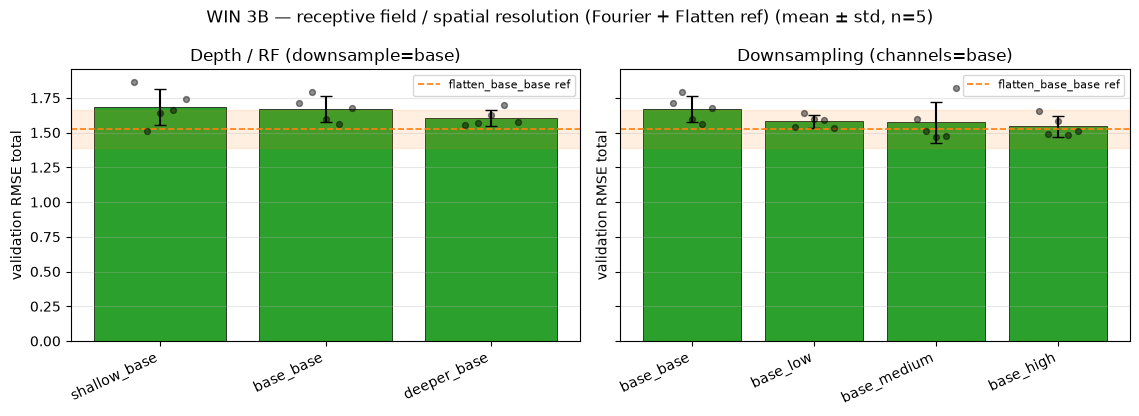

- Aggregated over n=5 training seeds (mean ± std validation RMSE).

- Depth / RF (downsample=base): best=fourier_deeper_base (mean val RMSE 1.606); Δmean=0.077 within combined std≈0.142 → inconclusive.

- Downsampling axis: best=fourier_base_high (mean val RMSE 1.545); Δmean=0.123 exceeds combined std≈0.119 → fourier_base_high better than fourier_base_base.

- Best Fourier (fourier_base_high) is +0.018 vs Flatten (within combined std≈0.157).

- Relative to Milestone 8 Step 3A: RF / resolution is a secondary check — large gaps vs Flatten usually reflect spatial readout, not RF alone.

In [6]:
fig_bars, fig_loss = plot_win3b_receptive_field_results(
    results_df,
    histories,
    runs_df=runs_df,
)
plt.show()
if fig_loss is not None:
    plt.show()

for line in summarize_win3b_receptive_field(results_df):
    display(Markdown(f"- {line}"))


## Conclusions

1. All effects are relatively small, showing that at least within the Fourier approach, the exact network details are not of major importance.
2. Deeper networks fair a bit better, in line with generally improved expressivity in deeper, rather than wider networks.
3. Downsampling the spatial dimension when going through the CNN does not create a bottleneck, on the contrary, it slightly improves localization. A possible interpretation is that downsampling the image dimensions, without making the kernel smaller, provides for more effective interaction between separate parts of the image, which may help in the localization task as the information is spread out widely throughout the image due to the broadening effect of the diffusion.

Given that the effects are rather minor, the canonical network architecture is maintained.

Do **not** freeze architecture here (Milestone 8 Step 3E). Did **not** touch the test split.


## Contract test


In [7]:
run_installed_pytest_test(m8_validation, "test_m8_3b_receptive_field_grid_is_bounded")


M8.3B
Test executed: test_m8_3b_receptive_field_grid_is_bounded()

pytest:
../../venv/lib/python3.12/site-packages/tomography_ml_validation/milestone_08/validation.py . [100%]
============================== 1 passed in 1.68s ===============================

Test proves: Milestone 8 Step 3B receptive-field grid is a small predefined set.
